# 1. LOAD & INSPECT DATASET

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
df=pd.read_csv("netflix_titles.csv")

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [8]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [9]:
df.describe()

,release_year
count,8807.000000
mean,2014.180198
std,8.819312
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


In [10]:
df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [11]:
df.dtypes

show_id         object
type            object
title           object
director        object
cast            object
country         object
date_added      object
release_year     int64
rating          object
duration        object
listed_in       object
description     object
dtype: object

In [12]:
df.shape

(8807, 12)

# 2. CLEANING 

In [13]:
df["director"]=df["director"].fillna("unknown")

In [14]:
df["cast"]=df["cast"].fillna("Not Available")

In [15]:
df["country"] = df["country"].fillna("Unknown")

In [16]:
df["date_added"] = pd.to_datetime(df["date_added"],errors="coerce")
df = df.dropna(subset=["date_added"])

In [17]:
df = df[~df["rating"].str.contains("min", case=False, na=False)]
df["rating"]=df["rating"].fillna(df["rating"].mode()[0])
df["rating"].value_counts()

rating
TV-MA       3187
TV-14       2133
TV-PG        838
R            799
PG-13        490
TV-Y7        330
TV-Y         300
PG           287
TV-G         212
NR            78
G             41
TV-Y7-FV       5
NC-17          3
UR             3
Name: count, dtype: int64

In [18]:
df["duration_time"] = df["duration"].str.extract(r'(\d+)').astype(int)
df["duration_time"].value_counts()

duration_time
1      1791
2       384
3       179
90      152
94      146
       ... 
189       1
273       1
212       1
224       1
191       1
Name: count, Length: 210, dtype: int64

In [19]:
df["duration_type"] = df["duration"].str.extract(r'([a-zA-Z]+)')
df["duration_type"] = df["duration_type"].replace("Season", "Seasons")
df["duration_type"].value_counts()

duration_type
min        6128
Seasons    2578
Name: count, dtype: int64

In [20]:
df = df.drop(columns=["duration"])

In [427]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8706 entries, 0 to 8806
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   show_id        8706 non-null   object        
 1   type           8706 non-null   object        
 2   title          8706 non-null   object        
 3   director       8706 non-null   object        
 4   cast           8706 non-null   object        
 5   country        8706 non-null   object        
 6   date_added     8706 non-null   datetime64[ns]
 7   release_year   8706 non-null   int64         
 8   rating         8706 non-null   object        
 9   listed_in      8706 non-null   object        
 10  description    8706 non-null   object        
 11  duration_time  8706 non-null   int64         
 12  duration_type  8706 non-null   object        
dtypes: datetime64[ns](1), int64(2), object(10)
memory usage: 952.2+ KB


In [21]:
df.head(10)

,show_id,type,title,director,cast,country,date_added,release_year,rating,listed_in,description,duration_time,duration_type
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Not Available,United States,2021-09-25,2020,PG-13,Documentaries,"As her father nears the end of his life, filmm...",90,min
1,s2,TV Show,Blood & Water,unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2,Seasons
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,2021-09-24,2021,TV-MA,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,1,Seasons
3,s4,TV Show,Jailbirds New Orleans,unknown,Not Available,Unknown,2021-09-24,2021,TV-MA,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",1,Seasons
4,s5,TV Show,Kota Factory,unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,2,Seasons
5,s6,TV Show,Midnight Mass,Mike Flanagan,"Kate Siegel, Zach Gilford, Hamish Linklater, H...",Unknown,2021-09-24,2021,TV-MA,"TV Dramas, TV Horror, TV Mysteries",The arrival of a charismatic young priest brin...,1,Seasons
6,s7,Movie,My Little Pony: A New Generation,"Robert Cullen, José Luis Ucha","Vanessa Hudgens, Kimiko Glenn, James Marsden, ...",Unknown,2021-09-24,2021,PG,Children & Family Movies,Equestria's divided. But a bright-eyed hero be...,91,min
7,s8,Movie,Sankofa,Haile Gerima,"Kofi Ghanaba, Oyafunmike Ogunlano, Alexandra D...","United States, Ghana, Burkina Faso, United Kin...",2021-09-24,1993,TV-MA,"Dramas, Independent Movies, International Movies","On a photo shoot in Ghana, an American model s...",125,min
8,s9,TV Show,The Great British Baking Show,Andy Devonshire,"Mel Giedroyc, Sue Perkins, Mary Berry, Paul Ho...",United Kingdom,2021-09-24,2021,TV-14,"British TV Shows, Reality TV",A talented batch of amateur bakers face off in...,9,Seasons
9,s10,Movie,The Starling,Theodore Melfi,"Melissa McCarthy, Chris O'Dowd, Kevin Kline, T...",United States,2021-09-24,2021,PG-13,"Comedies, Dramas",A woman adjusting to life after a loss contend...,104,min


# Data Cleaning explanation

# 1. Handling Missing Values in "director"
Missing values in the director column were replaced with "Unknown". This ensures that no records are lost during analysis while clearly indicating unavailable information, allowing the column to remain usable for categorical analysis.


# 2. Handling Missing Values in "cast"
Missing entries in the cast column were filled with "Not Available". This preserves all rows in the dataset and avoids issues during analysis that may arise from null values in text-based fields.


# 3. Handling Missing Values in "country"
Null values in the country column were replaced with "Unknown". This prevents loss of data and allows the column to still be used for grouping and aggregation without errors.


# 4. Cleaning and Converting "date_added"
The date_added  column was converted to datetime format using pd.to_datetime(). Any invalid or unparseable dates were coerced into null values and subsequently removed. This ensures that time-based analysis (such as trends over years) is accurate and reliable.


# 5. Cleaning the "rating" Column
Rows containing invalid entries (such as duration-related values like "min") in the rating column were removed, as they do not represent actual ratings. Remaining missing values were filled using the mode (most frequent value), ensuring consistency and preserving the dataset.


# 6. Extracting and Transforming "duration"
The original duration column contained mixed information (e.g., "90 min", "2 Seasons"). This was split into two new columns:
- duration_time: numerical value extracted using regex
- duration_type: unit of measurement (minutes or seasons)

Additionally, inconsistent labels such as "Season" were standardized to "Seasons" for uniformity. The original duration` column was then dropped, as it was no longer needed.

# 3. GROUP BY & VISUALIZATIONS

In [22]:
df["year_added"] = df["date_added"].dt.year
yearly_content = df.groupby("year_added")["show_id"].count()
yearly_content

year_added
2008       2
2009       2
2010       1
2011      13
2012       3
2013      10
2014      23
2015      73
2016     416
2017    1163
2018    1625
2019    1999
2020    1878
2021    1498
Name: show_id, dtype: int64

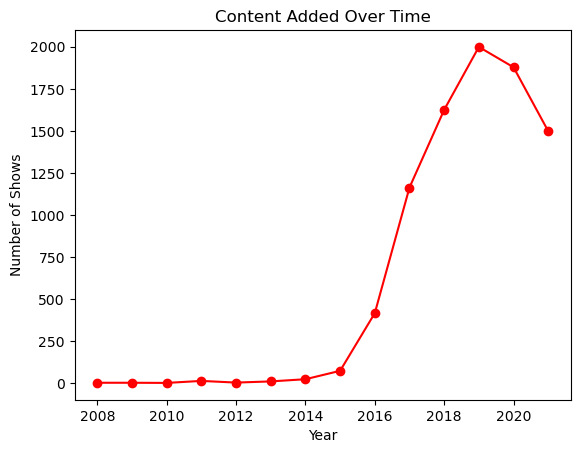

In [23]:
yearly_content.plot(kind="line", marker="o",color="red")
plt.title("Content Added Over Time")
plt.xlabel("Year")
plt.ylabel("Number of Shows")
plt.show()

# Content Growth Over Time

The number of shows added to Netflix has increased significantly over the years, especially after 2015. This indicates rapid expansion of the platform’s content library and growing investment in content acquisition.

In [24]:
type_counts = df.groupby("type")["show_id"].count()
type_counts

type
Movie      6128
TV Show    2578
Name: show_id, dtype: int64

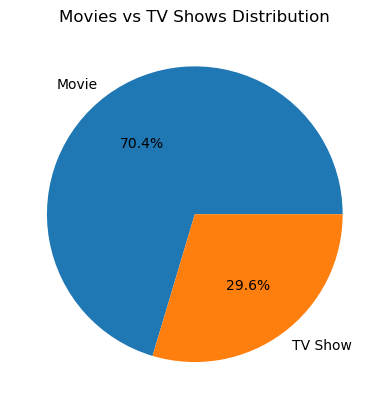

In [25]:
plt.pie(type_counts, labels=type_counts.index, autopct="%1.1f%%")
plt.title("Movies vs TV Shows Distribution")
plt.show()

# Movies vs TV Shows Distribution

Movies make up a larger proportion of the dataset compared to TV shows. This suggests that Netflix focuses more on movie content, possibly due to faster production and higher demand.

In [30]:
country_counts = df.groupby("country")["show_id"].count().sort_values(ascending=False).head(10)
country_counts

country
United States     2775
India              971
Unknown            827
United Kingdom     403
Japan              241
South Korea        195
Canada             173
Spain              141
France             122
Mexico             110
Name: show_id, dtype: int64

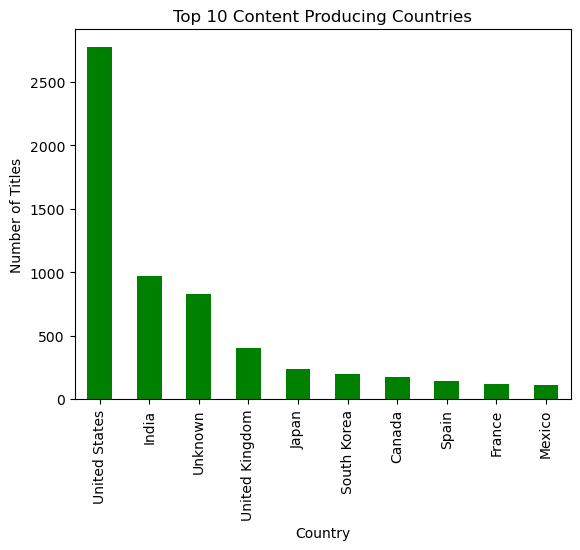

In [31]:
country_counts.plot(kind="bar",color="green")
plt.title("Top 10 Content Producing Countries")
plt.xlabel("Country")
plt.ylabel("Number of Titles")
plt.show()

# Top Content Producing Countries

The United States dominates content production by a large margin, followed by a few other countries. This shows that content creation is heavily concentrated in specific regions.

In [32]:
release_trend = df.groupby("release_year")["show_id"].count()
release_trend = release_trend.sort_index()
release_trend

release_year
1925       1
1942       2
1943       3
1944       3
1945       4
        ... 
2017    1015
2018    1140
2019    1030
2020     953
2021     592
Name: show_id, Length: 74, dtype: int64

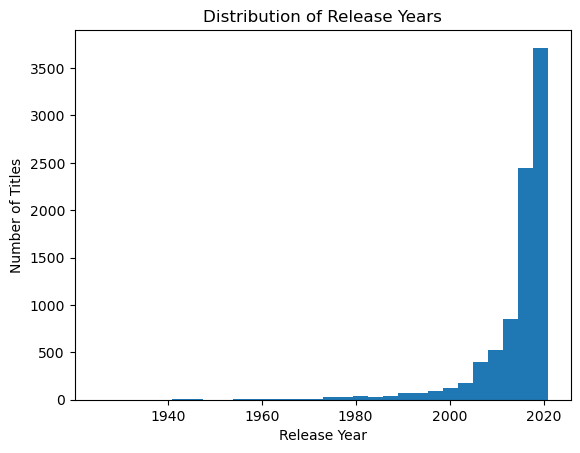

In [33]:
plt.hist(df["release_year"], bins=30)
plt.title("Distribution of Release Years")
plt.xlabel("Release Year")
plt.ylabel("Number of Titles")
plt.show()

# Release Year Distribution

The distribution shows that most content comes from recent years, especially after 2000. This indicates that Netflix primarily focuses on modern content rather than older productions, aligning with current audience preferences.

# Key Observations

1. The number of titles added to the platform shows a sharp upward trend, particularly after 2015. This suggests a phase of aggressive content expansion, likely driven by increased competition in the streaming industry and a strategic push to attract and retain subscribers through a larger content library.

2. The United States contributes the highest number of titles by a significant margin, indicating a strong dominance in content production. This may reflect both the scale of the US entertainment industry and Netflix’s reliance on US-based content to appeal to a global audience.

3. The distribution of ratings reveals that a substantial portion of content is categorized under mature audience ratings such as TV-MA and R. This indicates that the platform primarily targets adult viewers, possibly due to higher engagement levels and broader storytelling flexibility in mature content.

4. The release year distribution shows a clear concentration of titles from the 21st century, particularly after 2000. This suggests that Netflix prioritizes relatively recent content, aligning with audience preferences for modern storytelling, updated production quality, and contemporary themes.

5. The dataset indicates that movies constitute a larger share of the content compared to TV shows. This may be due to shorter production cycles and lower long-term commitment required for movies, allowing the platform to scale its content library more rapidly compared to episodic series.

# What I would explore next

1. I would analyze trends in content addition over months to identify seasonal patterns.

2. I would explore the listed_in column to understand which genres are most popular.

3. I would investigate how content ratings vary across different countries.